# DemoMA_MCClassification_CCGPFL_GPyTorch_SemiSynthetic

This demo shows an example of Multi-class classification with multiple annotators by using our model based on correlated chained Gaussian processes for multiple annotators with focal loss (CCGGFL) over a dataset from the UCI repository, where the multi-labeler information are simulated by the methdology used in the paper.


In [1]:
!pip install -q gpytorch ucimlrepo


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.2/291.2 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.8/174.8 kB 20.7 MB/s eta 0:00:00


In [2]:
from pathlib import Path
import random
import warnings
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import gpytorch

from sklearn.datasets import load_iris
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    mean_absolute_error,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm


warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")


Device: cuda


In [3]:
# Clone the repo containig useful functions and the model
!git clone https://github.com/juliangilg/CCGPCR.git
sys.path.append('/content/CCGPCR')

Cloning into 'CCGPCR'...
remote: Enumerating objects: 53, done.
remote: Counting objects: 100% (53/53), done.
remote: Compressing objects: 100% (53/53), done.
remote: Total 53 (delta 26), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (53/53), 557.24 KiB | 2.96 MiB/s, done.
Resolving deltas: 100% (26/26), done.


In [4]:
# Loading useful funtions
from utils import *
from ccgpfl_gpytorch import MultiClassMA, MultitaskGPModel,build_ccgpma

## 1. Download the Iris dataset



In [5]:

from ucimlrepo import fetch_ucirepo

iris = fetch_ucirepo(id=53)
X_df = iris.data.features.copy()
y_raw = iris.data.targets.iloc[:, 0].astype(str)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)
class_names = label_encoder.classes_

print(f"Number of instances: {X_df.shape[0]}")
print(f"Number of input features: {X_df.shape[1]}")
print(f"Classes: {list(class_names)}")

display(X_df.head())


Number of instances: 150
Number of input features: 4
Classes: ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']


,sepal length,sepal width,petal length,petal width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## 2. Training and test sets


In [6]:
X_train_raw, X_test_raw, ytrain, ytest = train_test_split(
    X_df.to_numpy(dtype=np.float32),
    y,
    test_size=0.30,
    random_state=SEED,
)

scaler = StandardScaler()
Xtrain = scaler.fit_transform(X_train_raw).astype(np.float32)
Xtest = scaler.transform(X_test_raw).astype(np.float32)

N, input_dim = Xtrain.shape
N_test = Xtest.shape[0]
K = len(class_names)

print(f"Training instances: {N}")
print(f"Test instances: {N_test}")
print(f"Input dimension: {input_dim}")
print(f"Number of classes: {K}")


Training instances: 105
Test instances: 45
Input dimension: 4
Number of classes: 3


## 3. Simulation of multiple annotators



In [7]:
W = 5 # Number of annotators
NrP = [N]*W # the percentage of samples labeled by each annotator

Z_w, Ytrain, iAnn, Vref = multiple_annotators(W, NrP, Xtrain.sum(1).reshape((-1,1)), ytrain+1)

## 4. Correlated Chained Gaussian Processes with Focal Loss for Multiple Annotators (CCGPFL)

We use the proposed CCGPFL framework to address multi-class classification problems with multiple annotators. The model builds on Correlated Chained Gaussian Processes for Multiple Annotators (CCGPMA), which estimate annotator-specific reliability as a function of the input features while capturing dependencies among annotators through correlated latent Gaussian processes. Unlike the original formulation, CCGPFL incorporates a focal-loss-based variational objective to mitigate the dominance of frequent annotation patterns and improve learning when sparse annotations induce class imbalance.


In [8]:
train_dataset = TensorDataset(
    torch.tensor(Xtrain, dtype=torch.float32),
    torch.tensor(Ytrain-1, dtype=torch.long),
)

# Full-batch training is convenient for this small dataset.
train_loader = DataLoader(
    train_dataset,
    batch_size=len(train_dataset),
    shuffle=True,
)


In [9]:
Q = K + W
J = K + W
M = 80

model, likelihood = build_ccgpma(
    num_classes=K,
    num_ann=W,
    inducing_p=M,
    num_latents=Q,
    input_dim=Xtrain.shape[1],
    initial_lengthscale=5,
    focal_gamma=0.1,
    num_likelihood_samples=200,
)

In [10]:
variational_ngd_optimizer = gpytorch.optim.NGD(model.variational_parameters(), num_data=Xtrain.shape[0], lr=0.01)

hyperparameter_optimizer = torch.optim.Adam([
    {'params': model.hyperparameters()},
    {'params': likelihood.parameters()},
], lr=0.005)

In [11]:
# We do this to use the GPU (if we only use CPU, the training will take a lot of time)
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# Assuming that we are on a CUDA machine, this should print a CUDA device:
print(device)

cuda:0


In [12]:
model.to(device)
likelihood.to(device)

MultiClassMA(
  (quadrature): GaussHermiteQuadrature1D()
)

In [13]:
model.train()
likelihood.train()
mll = gpytorch.mlls.VariationalELBO(likelihood, model, num_data=Xtrain.shape[0])

logf = []
num_epochs = 500
for i in range(num_epochs):

    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        ### Perform NGD step to optimize variational parameters
        variational_ngd_optimizer.zero_grad()
        hyperparameter_optimizer.zero_grad()

        output = model(x_batch)
        loss = -mll(output, y_batch)

        loss.backward()
        variational_ngd_optimizer.step()
        hyperparameter_optimizer.step()

    if i % 10 == 0:
      elbo = loss.item()
      logf.append(elbo)

Text(0, 0.5, 'ELBO')

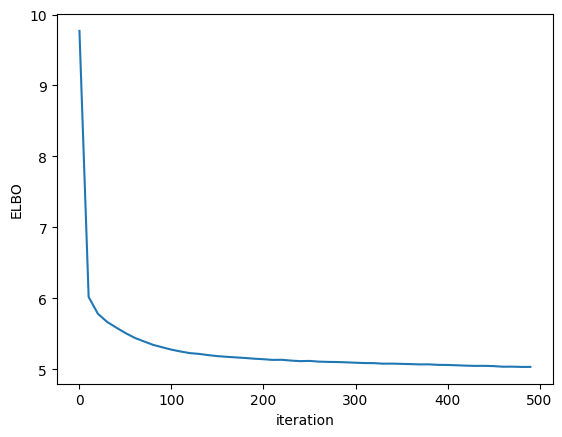

In [14]:
plt.plot(np.arange(num_epochs)[::10], logf)
plt.xlabel("iteration")
plt.ylabel("ELBO")

## 5. Prediction and performance assessment


In [15]:
model.eval()
likelihood.eval()

X_test_tensor = torch.tensor(Xtest, dtype=torch.float32).to(DEVICE)

with torch.no_grad():
    predictive_mean, predictive_variance = likelihood(model(X_test_tensor))

predictive_mean = predictive_mean.cpu().numpy()
predictive_variance = predictive_variance.cpu().numpy()

class_probabilities = predictive_mean[:, :K]
predicted_reliabilities = predictive_mean[:, K:]
y_pred_ccgpfl = class_probabilities.argmax(axis=1)


y_test_binarized = label_binarize(ytest, classes=np.arange(K))

performance_rows = [
    {
        "Method": "CCGPFL",
        "Accuracy": accuracy_score(ytest, y_pred_ccgpfl),
        "Balanced accuracy": balanced_accuracy_score(ytest, y_pred_ccgpfl),
        "Macro F1": f1_score(ytest, y_pred_ccgpfl, average="macro"),
        "Macro ROC-AUC (OvR)": roc_auc_score(
            y_test_binarized,
            class_probabilities,
            multi_class="ovr",
            average="macro",
        ),
        "Evaluated instances": len(ytest),
    },
]

performance = pd.DataFrame(performance_rows)
display(performance.style.format({
    "Accuracy": "{:.4f}",
    "Balanced accuracy": "{:.4f}",
    "Macro F1": "{:.4f}",
    "Macro ROC-AUC (OvR)": "{:.4f}",
}))


,Method,Accuracy,Balanced accuracy,Macro F1,Macro ROC-AUC (OvR),Evaluated instances
0,CCGPFL,0.9556,0.9487,0.9484,1.0000,45


Classification report for CCGPFL
                 precision    recall  f1-score   support

    Iris-setosa     1.0000    1.0000    1.0000        19
Iris-versicolor     1.0000    0.8462    0.9167        13
 Iris-virginica     0.8667    1.0000    0.9286        13

       accuracy                         0.9556        45
      macro avg     0.9556    0.9487    0.9484        45
   weighted avg     0.9615    0.9556    0.9553        45



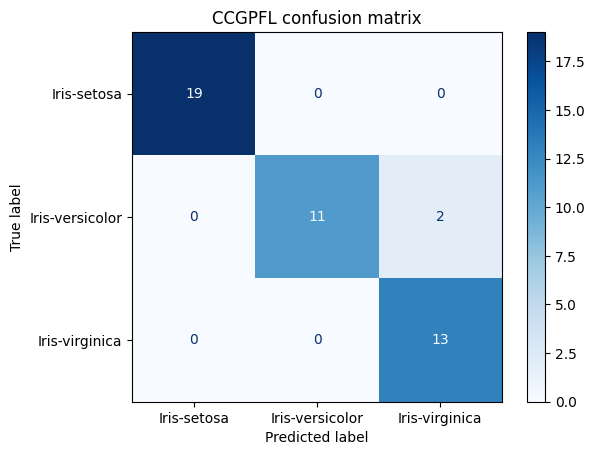

In [16]:
print("Classification report for CCGPFL")
print(
    classification_report(
        ytest,
        y_pred_ccgpfl,
        target_names=class_names,
        digits=4,
    )
)

ConfusionMatrixDisplay.from_predictions(
    ytest,
    y_pred_ccgpfl,
    display_labels=class_names,
    cmap="Blues",
)
plt.title("CCGPFL confusion matrix")
plt.show()
